# Entrenamiento y Optimización de Support Vector Machine (SVM) para sEMG

Este cuadernillo se encarga de entrenar, optimizar y evaluar un clasificador de vectores de soporte (**Support Vector Machine - SVM**) utilizando las 5 características temporales extraídas y escaladas previamente.

## Carga de Librerías y Vectores de Características

In [1]:
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score

# Función puramente robusta para buscar y cargar el archivo .env
def load_env_variables():
    import os
    from pathlib import Path
    
    # 1. Buscar .env subiendo niveles desde el CWD actual
    try:
        start_dir = Path(os.getcwd())
    except:
        start_dir = Path(".")
        
    env_path = None
    for path in [start_dir] + list(start_dir.parents):
        temp_path = path / ".env"
        if temp_path.exists():
            env_path = temp_path
            break
            
    if env_path is None:
        raise FileNotFoundError("⚠️ No se pudo encontrar el archivo .env en la raíz del proyecto.")
        
    # 2. Leer e inyectar variables en os.environ
    with open(env_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("#"):
                continue
            if "=" not in line:
                continue
            key, val = line.split("=", 1)
            os.environ[key.strip()] = val.strip()
            
    print(f"✅ Archivo .env cargado con éxito desde: {env_path}")

load_env_variables()


# 1. Definición de rutas y carga de datos preprocesados
base_path = os.environ["PROCESSED_VECTOR_CLASSIC_PROTO"]

print("📖 Cargando tensores de características escalados y etiquetas...")
X_train = np.load(os.path.join(base_path, 'X_train_scaled.npy'))
X_test  = np.load(os.path.join(base_path, 'X_test_scaled.npy'))
y_train = np.load(os.path.join(base_path, 'y_train.npy'))
y_test  = np.load(os.path.join(base_path, 'y_test.npy'))

print(f"✅ Conjunto de Entrenamiento (Train): X={X_train.shape} | y={y_train.shape}")
print(f"✅ Conjunto de Prueba (Test):         X={X_test.shape}  | y={y_test.shape}")
print(f"Clases detectadas para clasificación: {np.unique(y_train)}")

✅ Archivo .env cargado con éxito desde: /home/cbe/Proyectos/MyoTensor_Tesis/.env
📖 Cargando tensores de características escalados y etiquetas...
✅ Conjunto de Entrenamiento (Train): X=(3259, 6) | y=(3259,)
✅ Conjunto de Prueba (Test):         X=(815, 6)  | y=(815,)
Clases detectadas para clasificación: [0 1 2 3]


## Optimización de Hiperparámetros (Grid Search CV)

Para exprimir el máximo rendimiento de la SVM con kernel de base radial (RBF) u otros kernels, debemos afinar sus dos hiperparámetros fundamentales:
1. **C (Regularización):** Controla el balance entre un margen de decisión amplio y la minimización de errores de entrenamiento.
2. **Gamma (Ancho de banda RBF):** Define qué tan lejos llega la influencia de un solo ejemplo de entrenamiento.

Utilizaremos **`GridSearchCV`** con una validación cruzada estratificada de 5 pliegues (**Stratified 5-Fold CV**) para asegurar que la evaluación sea estadísticamente sólida.

In [2]:
print("Configurando Grid Search Cross-Validation...")

# Definición de la grilla de parámetros
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'sigmoid']
}

# Instanciar el clasificador base SVM
svm_base = SVC(class_weight='balanced', random_state=42)

# Validación cruzada estratificada de 5 folds
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Instanciar la búsqueda por grilla
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Iniciando entrenamiento y búsqueda exhaustiva en paralelo...")
grid_search.fit(X_train, y_train)

print("\n--- Resultados del Grid Search ---")
print(f"   * Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"   * Mejor Exactitud en CV:    {grid_search.best_score_*100:.2f}%")

Configurando Grid Search Cross-Validation...
Iniciando entrenamiento y búsqueda exhaustiva en paralelo...
Fitting 5 folds for each of 90 candidates, totalling 450 fits

--- Resultados del Grid Search ---
   * Mejores Hiperparámetros: {'C': 1000, 'gamma': 'scale', 'kernel': 'rbf'}
   * Mejor Exactitud en CV:    70.21%


## Evaluación del Mejor Modelo en el Conjunto de Prueba (Test Set)

🎯 Test Accuracy (Exactitud en Test Set): 70.67%

--- Reporte de Clasificación Detallado ---
              precision    recall  f1-score   support

  Reposo (0)       0.97      0.99      0.98       282
   Palma (1)       0.53      0.56      0.54       138
    Puño (2)       0.62      0.54      0.58       215
     Paz (3)       0.53      0.57      0.55       180

    accuracy                           0.71       815
   macro avg       0.66      0.67      0.66       815
weighted avg       0.71      0.71      0.71       815



<Figure size 800x600 with 0 Axes>

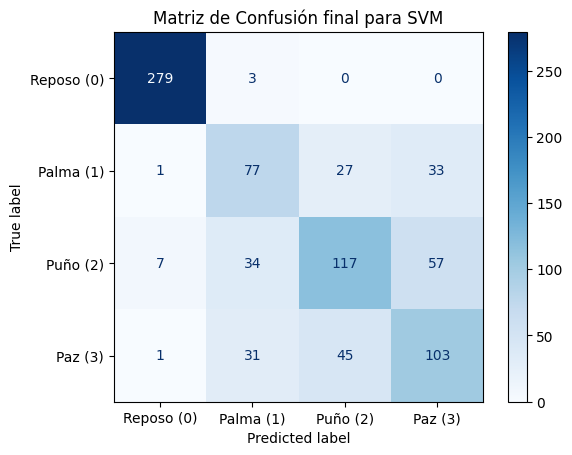

In [3]:
# 1. Obtener el modelo óptimo entrenado
best_svm = grid_search.best_estimator_

# 2. Realizar predicciones sobre el Test Set
y_pred = best_svm.predict(X_test)

# 3. Calcular métricas globales
test_accuracy = accuracy_score(y_test, y_pred)
print(f"🎯 Test Accuracy (Exactitud en Test Set): {test_accuracy*100:.2f}%")

# 4. Reporte de Clasificación Detallado
class_names = ['Reposo (0)', 'Palma (1)', 'Puño (2)', 'Paz (3)']
print("\n--- Reporte de Clasificación Detallado ---")
print(classification_report(y_test, y_pred, target_names=class_names))

# 5. Matriz de Confusión Estética
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title('Matriz de Confusión final para SVM')
plt.show()

## Exportación del Modelo SVM Optimizado

In [4]:
# Asegurar que la carpeta models/classic exista en el proyecto desde el .env
models_dir = os.environ["MODELS_ML_PROTO"]
os.makedirs(models_dir, exist_ok=True)

# Corrección de gamma para compatibilidad con micromlgen
if best_svm.gamma == 'auto':
    best_svm.gamma = 1.0 / 6.0
elif best_svm.gamma == 'scale':
    best_svm.gamma = 1.0 / (6.0 * X_train.var())

model_filename = 'svm_model.bin'
model_path = os.path.join(models_dir, model_filename)

print(f"💾 Guardando el clasificador SVM optimizado en: {model_path} ...")
joblib.dump(best_svm, model_path)

# Guardar también el StandardScaler ajustado en la misma carpeta para la transpilación
base_path = os.environ["PROCESSED_VECTOR_CLASSIC_PROTO"]
scaler_src = os.path.join(base_path, 'features_scaler.bin')
scaler_dst = os.path.join(models_dir, 'feature_scaler.bin')
if os.path.exists(scaler_src):
    print(f"💾 Guardando el StandardScaler ajustado en: {scaler_dst} ...")
    scaler = joblib.load(scaler_src)
    joblib.dump(scaler, scaler_dst)
else:
    print("⚠️ Advertencia: No se encontró 'features_scaler.bin' en la ruta de procesamiento.")

print("\n¡Guardado final completado con éxito!")

💾 Guardando el clasificador SVM optimizado en: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/ml/svm_model.bin ...
💾 Guardando el StandardScaler ajustado en: /home/cbe/Proyectos/MyoTensor_Tesis/intelligence/models/myotensor_proto/ml/feature_scaler.bin ...

¡Guardado final completado con éxito!
